In [ ]:
!pip -q install kagglehub

In [ ]:
import os
import random
import math
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponível:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
caminho_download = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset baixado em:", caminho_download)

100%|██████████| 5.20G/5.20G [00:35<00:00, 159MB/s]

Extracting files...


Dataset baixado em: /root/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2


In [ ]:
raiz = Path(caminho_download)

arquivos_csv = list(raiz.rglob("HAM10000_metadata.csv"))

caminho_metadata = arquivos_csv[0]
df = pd.read_csv(caminho_metadata)

mapa_imagens = {
    caminho.stem: str(caminho)
    for caminho in raiz.rglob("*.jpg")
}

df["caminho_imagem"] = df["image_id"].map(mapa_imagens)
df = df.dropna(subset=["caminho_imagem"]).copy()

nomes_classes = {
    "akiec": "queratose_actinica_carcinoma_intraepitelial",
    "bcc": "carcinoma_basocelular",
    "bkl": "lesao_benigna_queratose",
    "df": "dermatofibroma",
    "mel": "melanoma",
    "nv": "nevo_melanocitico",
    "vasc": "lesao_vascular"
}

df["classe_descritiva"] = df["dx"].map(nomes_classes)

display(df.head())
print("Total de imagens com caminho encontrado:", len(df))
print("Classes:", sorted(df["dx"].unique()))

,lesion_id,image_id,dx,dx_type,age,sex,localization,caminho_imagem,classe_descritiva
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/root/.cache/kagglehub/datasets/kmader/skin-ca...,lesao_benigna_queratose
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/root/.cache/kagglehub/datasets/kmader/skin-ca...,lesao_benigna_queratose
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/root/.cache/kagglehub/datasets/kmader/skin-ca...,lesao_benigna_queratose
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/root/.cache/kagglehub/datasets/kmader/skin-ca...,lesao_benigna_queratose
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/root/.cache/kagglehub/datasets/kmader/skin-ca...,lesao_benigna_queratose


Total de imagens com caminho encontrado: 10015
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


## Preparação dos dados


In [ ]:
treino_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["dx"],
    random_state=SEED
)

validacao_df, teste_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["dx"],
    random_state=SEED
)

print("Treino:", treino_df.shape)
print("Validação:", validacao_df.shape)
print("Teste:", teste_df.shape)

print("\nDistribuição no treino:")
display(treino_df["dx"].value_counts(normalize=True).round(3))

Treino: (7010, 9)
Validação: (1502, 9)
Teste: (1503, 9)

Distribuição no treino:


,proportion
dx,
nv,0.669
mel,0.111
bkl,0.110
bcc,0.051
akiec,0.033
vasc,0.014
df,0.012


In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

gerador_treino = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True
)

gerador_validacao_teste = ImageDataGenerator(
    rescale=1./255
)

treino_gen = gerador_treino.flow_from_dataframe(
    dataframe=treino_df,
    x_col="caminho_imagem",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

validacao_gen = gerador_validacao_teste.flow_from_dataframe(
    dataframe=validacao_df,
    x_col="caminho_imagem",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

teste_gen = gerador_validacao_teste.flow_from_dataframe(
    dataframe=teste_df,
    x_col="caminho_imagem",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

classes_modelo = list(treino_gen.class_indices.keys())
num_classes = len(classes_modelo)

print("Classes usadas pelo modelo:", classes_modelo)
print("Número de classes:", num_classes)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.
Classes usadas pelo modelo: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Número de classes: 7


In [ ]:
# Pesos das classes.
pesos = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(treino_gen.classes),
    y=treino_gen.classes
)

class_weight = dict(zip(np.unique(treino_gen.classes), pesos))
class_weight

{np.int64(0): np.float64(4.37305053025577),
 np.int64(1): np.float64(2.7817460317460316),
 np.int64(2): np.float64(1.3022478172023035),
 np.int64(3): np.float64(12.36331569664903),
 np.int64(4): np.float64(1.285530900421786),
 np.int64(5): np.float64(0.21338772031292808),
 np.int64(6): np.float64(10.115440115440116)}

In [ ]:
modelo = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Conv2D(32, kernel_size=3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, kernel_size=3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, kernel_size=3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.50),
    layers.Dense(num_classes, activation="softmax")
])

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,927 (1.75 MB)

 Trainable params: 456,967 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

## Treinamento



In [ ]:
EPOCHS = 15

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6
    )
]

historico = modelo.fit(
    treino_gen,
    validation_data=validacao_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 113s 465ms/step - accuracy: 0.3906 - loss: 1.8284 - val_accuracy: 0.0513 - val_loss: 2.2780 - learning_rate: 0.0010
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 82s 373ms/step - accuracy: 0.4484 - loss: 1.5407 - val_accuracy: 0.0912 - val_loss: 2.4082 - learning_rate: 0.0010
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 78s 354ms/step - accuracy: 0.4646 - loss: 1.4668 - val_accuracy: 0.4887 - val_loss: 1.3382 - learning_rate: 0.0010
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 78s 353ms/step - accuracy: 0.4862 - loss: 1.3776 - val_accuracy: 0.2031 - val_loss: 5.2130 - learning_rate: 0.0010
Epoch 5/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 77s 349ms/step - accuracy: 0.4989 - loss: 1.3817 - val_accuracy: 0.4760 - val_loss: 1.3666 - learning_rate: 0.0010
Epoch 6/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 78s 352ms/step - accuracy: 0.5315 - loss: 1.2782 - val_accuracy: 0.3668 - val_loss: 1.7155 - learning_rate: 3.0000e-04
Epoch 7/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 79s 358ms/step - accuracy

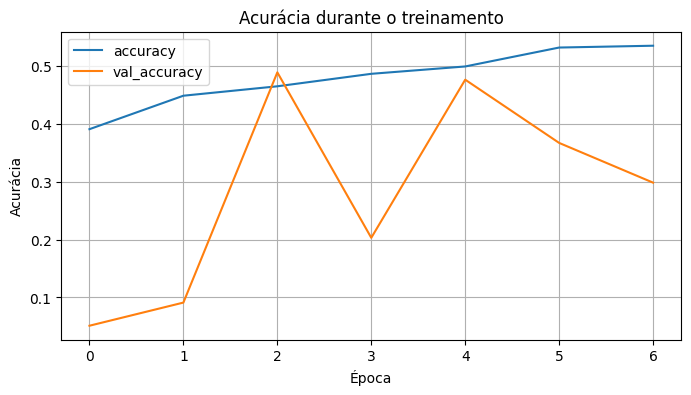

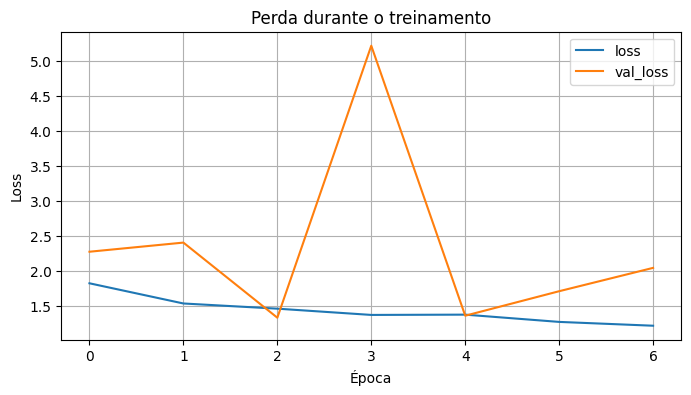

In [ ]:
# Gráficos do treinamento.

pd.DataFrame(historico.history)[["accuracy", "val_accuracy"]].plot(figsize=(8, 4))
plt.title("Acurácia durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.grid(True)
plt.show()

pd.DataFrame(historico.history)[["loss", "val_loss"]].plot(figsize=(8, 4))
plt.title("Perda durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
resultado_teste = modelo.evaluate(teste_gen, verbose=0)
print(f"Loss no teste: {resultado_teste[0]:.4f}")
print(f"Acurácia no teste: {resultado_teste[1]:.4f}")

Loss no teste: 1.3889
Acurácia no teste: 0.4790


In [ ]:
teste_gen.reset()

probabilidades = modelo.predict(teste_gen, verbose=1)
y_predito = np.argmax(probabilidades, axis=1)
y_real = teste_gen.classes

idx_para_classe = {v: k for k, v in teste_gen.class_indices.items()}
nomes_ordenados = [idx_para_classe[i] for i in range(len(idx_para_classe))]

print(classification_report(
    y_real,
    y_predito,
    target_names=nomes_ordenados,
    zero_division=0
))

47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 194ms/step
              precision    recall  f1-score   support

       akiec       0.12      0.61      0.20        49
         bcc       0.28      0.10      0.15        77
         bkl       0.28      0.54      0.37       165
          df       0.05      0.24      0.08        17
         mel       0.29      0.53      0.38       167
          nv       0.97      0.49      0.65      1006
        vasc       0.31      0.23      0.26        22

    accuracy                           0.48      1503
   macro avg       0.33      0.39      0.30      1503
weighted avg       0.73      0.48      0.54      1503



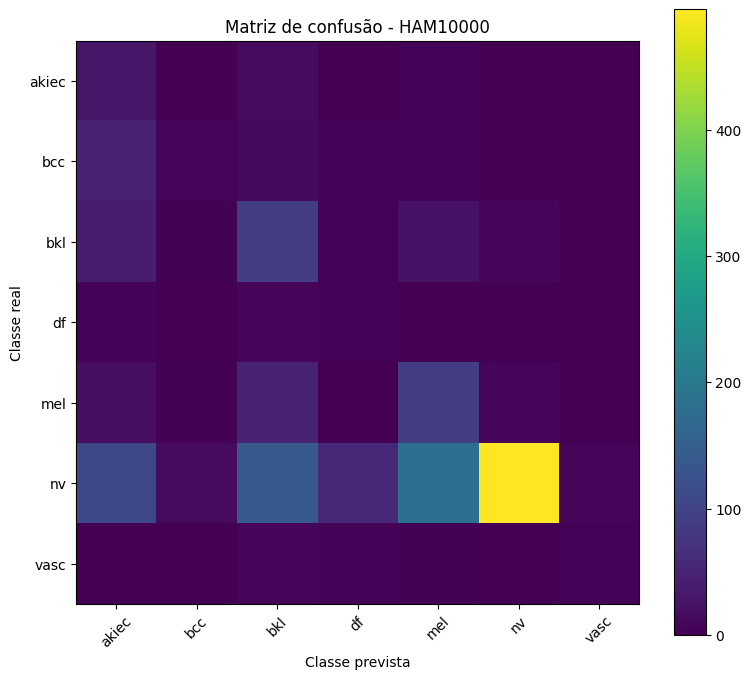

In [ ]:
matriz = confusion_matrix(y_real, y_predito)

plt.figure(figsize=(8, 7))
plt.imshow(matriz)
plt.title("Matriz de confusão - HAM10000")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.xticks(range(len(nomes_ordenados)), nomes_ordenados, rotation=45)
plt.yticks(range(len(nomes_ordenados)), nomes_ordenados)
plt.colorbar()
plt.tight_layout()
plt.show()

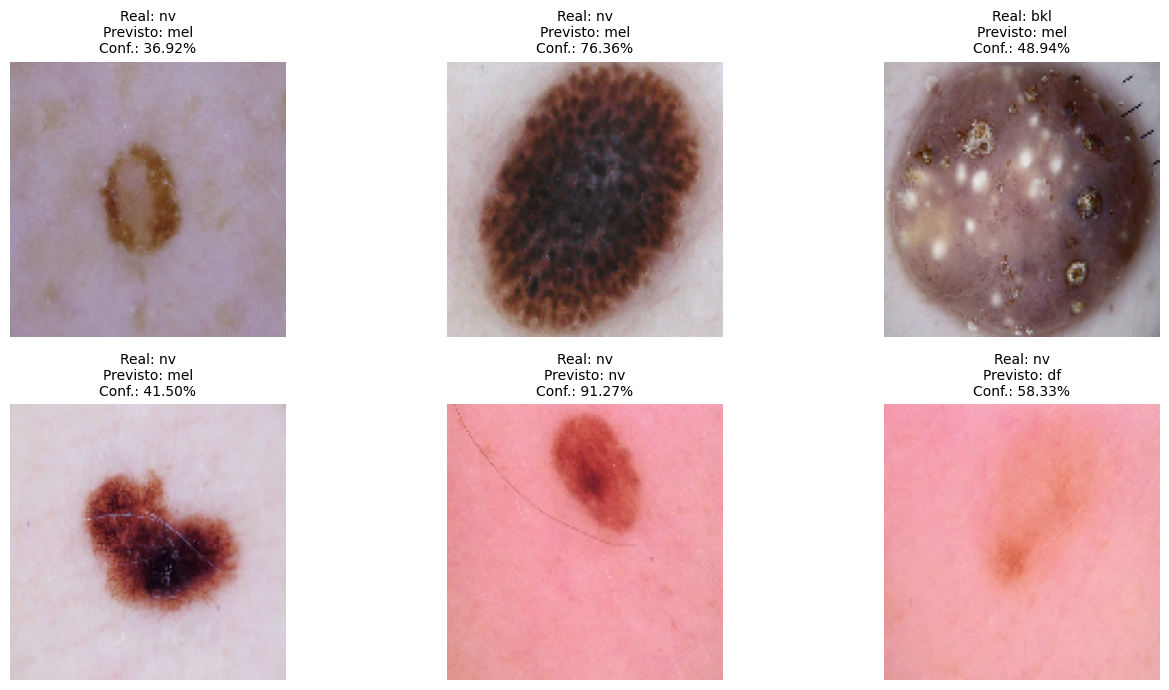

In [ ]:
def demonstrar_previsoes_pele(teste_df, modelo, qtd=6):
    amostra = teste_df.sample(qtd, random_state=SEED).reset_index(drop=True)

    plt.figure(figsize=(14, 7))

    for i, linha in amostra.iterrows():
        caminho = linha["caminho_imagem"]
        classe_real = linha["dx"]

        img = tf.keras.utils.load_img(caminho, target_size=IMG_SIZE)
        array = tf.keras.utils.img_to_array(img) / 255.0
        array = np.expand_dims(array, axis=0)

        prob = modelo.predict(array, verbose=0)[0]
        indice = np.argmax(prob)
        classe_prevista = idx_para_classe[indice]
        confianca = prob[indice]

        plt.subplot(2, math.ceil(qtd / 2), i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"Real: {classe_real}\nPrevisto: {classe_prevista}\nConf.: {confianca:.2%}",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

demonstrar_previsoes_pele(teste_df, modelo, qtd=6)

In [ ]:
def prever_lesao(caminho_imagem):
    img = tf.keras.utils.load_img(caminho_imagem, target_size=IMG_SIZE)
    array = tf.keras.utils.img_to_array(img) / 255.0
    array = np.expand_dims(array, axis=0)

    probabilidades = modelo.predict(array, verbose=0)[0]
    indice = np.argmax(probabilidades)

    classe_curta = idx_para_classe[indice]
    classe_texto = nomes_classes.get(classe_curta, classe_curta)

    print("Classe prevista:", classe_curta)
    print("Descrição:", classe_texto)
    print("Confiança:", f"{probabilidades[indice]:.2%}")

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{classe_curta} — {probabilidades[indice]:.2%}")
    plt.show()